<a href="https://colab.research.google.com/github/Asif1900/Programming-for-Data-Analysis-Project/blob/main/Programming_for_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [54]:
df = pd.read_csv("all_cities_combined.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [55]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 140256
Number of columns: 18


In [56]:
df.columns.tolist()

['No',
 'year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'station']

In [57]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [58]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137163.000000,137915.000000,137511.000000,135690.000000,132363.000000,136664.000000,140112.000000,140113.000000,140110.000000,140110.000000,140136.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,77.481501,101.399508,15.811354,47.129503,1192.068962,57.692177,13.347028,1009.939314,2.328893,0.064937,1.768796
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.366874,89.753213,21.822958,32.961087,1100.290695,56.140181,11.506183,10.479821,13.856002,0.826774,1.252547
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,20.000000,35.000000,2.000000,22.000000,500.000000,13.000000,3.000000,1001.500000,-9.200000,0.000000,0.900000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,53.000000,79.000000,7.000000,39.000000,900.000000,45.000000,14.300000,1009.500000,2.900000,0.000000,1.400000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,108.000000,141.000000,20.000000,65.696000,1500.000000,81.000000,23.100000,1018.100000,15.000000,0.000000,2.200000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,315.000000,270.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,72.500000,12.900000


In [59]:
df.describe(include='object')

,wd,station
count,139655,140256
unique,16,4
top,NW,Dongsi
freq,13107,35064


In [60]:
df['station'].value_counts()

,count
station,
Dongsi,35064
Guanyuan,35064
Changping,35064
Huairou,35064


In [61]:
selected_stations = ['Dongsi', 'Guanyuan', 'Changping', 'Huairou']
df = df[df['station'].isin(selected_stations)].copy()

print(df['station'].value_counts())
print(df.shape)

station
Dongsi       35064
Guanyuan     35064
Changping    35064
Huairou      35064
Name: count, dtype: int64
(140256, 18)


In [62]:
df.to_csv("selected_stations_combined.csv", index=False)
print("Filtered dataset saved as selected_stations_combined.csv")

Filtered dataset saved as selected_stations_combined.csv


In [63]:
def missing_values_table(dataframe):
    missing_count = dataframe.isnull().sum()
    missing_percent = (missing_count / len(dataframe)) * 100

    table = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent
    })

    table = table.sort_values(by='Percentage (%)', ascending=False)
    return table

In [64]:
missing_table = missing_values_table(df)
missing_table

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [65]:
missing_table.style.background_gradient(cmap='Blues')

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [66]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [67]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (140256, 18)


In [68]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df[['year', 'month', 'day', 'hour', 'datetime']].head()

,year,month,day,hour,datetime
0,2013,3,1,0,2013-03-01 00:00:00
1,2013,3,1,1,2013-03-01 01:00:00
2,2013,3,1,2,2013-03-01 02:00:00
3,2013,3,1,3,2013-03-01 03:00:00
4,2013,3,1,4,2013-03-01 04:00:00


In [69]:
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)

In [70]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

In [71]:
if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

In [72]:
missing_values_table(df)

,Missing Values,Percentage (%)
No,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
hour,0,0.0
PM2.5,0,0.0
PM10,0,0.0
SO2,0,0.0
NO2,0,0.0
CO,0,0.0


In [73]:
df['day_of_week'] = df['datetime'].dt.day_name()
df['month_name'] = df['datetime'].dt.month_name()
df['weekend'] = df['datetime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

In [74]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

In [75]:
df['area_type'] = df['station'].map({
    'Dongsi': 'Urban',
    'Guanyuan': 'Urban',
    'Changping': 'Suburban',
    'Huairou': 'Suburban'
})

In [76]:
def pm25_category(value):
    if pd.isna(value):
        return np.nan
    elif value <= 35:
        return 'Good'
    elif value <= 75:
        return 'Moderate'
    elif value <= 115:
        return 'Unhealthy for Sensitive'
    elif value <= 150:
        return 'Unhealthy'
    elif value <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['PM2.5_Level'] = df['PM2.5'].apply(pm25_category)

In [77]:
df.to_csv("cleaned_selected_air_quality.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
df.info()

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Make sure datetime exists
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")

# Keep only selected stations if needed
selected_stations = ["Dongsi", "Guanyuan", "Changping", "Huairou"]
df = df[df["station"].isin(selected_stations)].copy()

# Area type
df["area_type"] = df["station"].map({
    "Dongsi": "Urban",
    "Guanyuan": "Urban",
    "Changping": "Suburban",
    "Huairou": "Suburban"
})

# Season
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    return "Winter"

df["season"] = df["month"].apply(get_season)
df["day_of_week"] = df["datetime"].dt.day_name()
df["weekend"] = df["datetime"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")

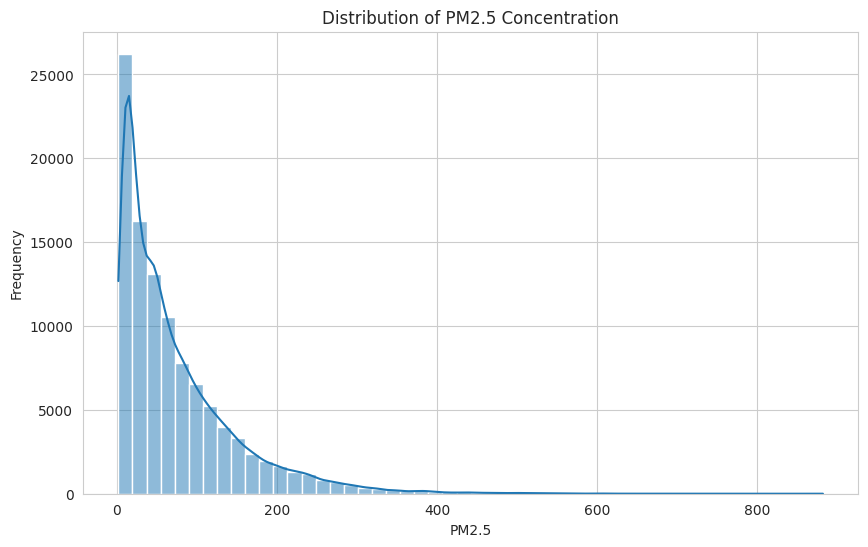

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(df["PM2.5"], bins=50, kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

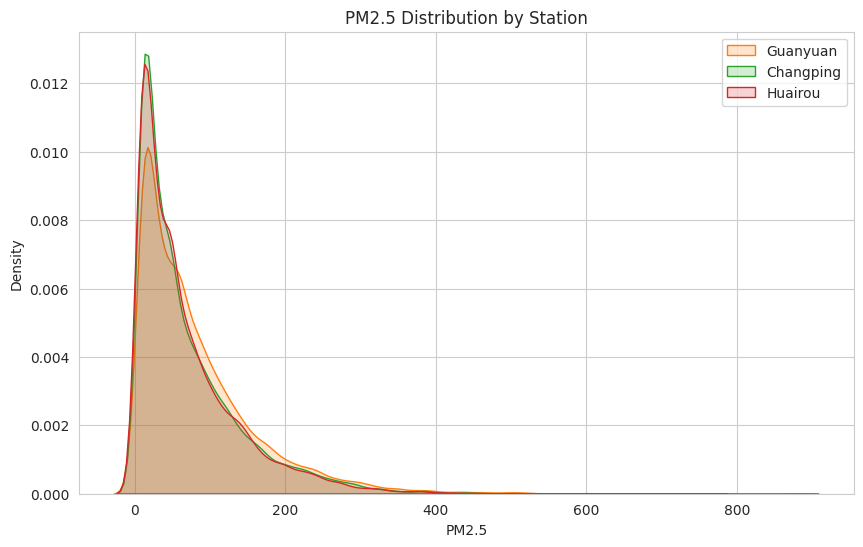

In [41]:
plt.figure(figsize=(10,6))
for station in selected_stations:
    sns.kdeplot(df[df["station"] == station]["PM2.5"], label=station, fill=True, alpha=0.2)
plt.title("PM2.5 Distribution by Station")
plt.xlabel("PM2.5")
plt.ylabel("Density")
plt.legend()
plt.show()

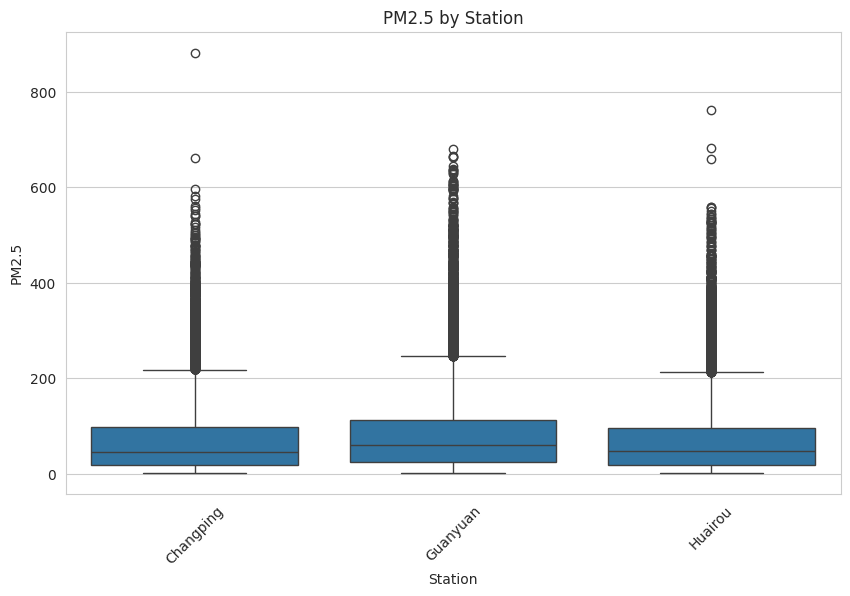

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="station", y="PM2.5")
plt.title("PM2.5 by Station")
plt.xlabel("Station")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)
plt.show()

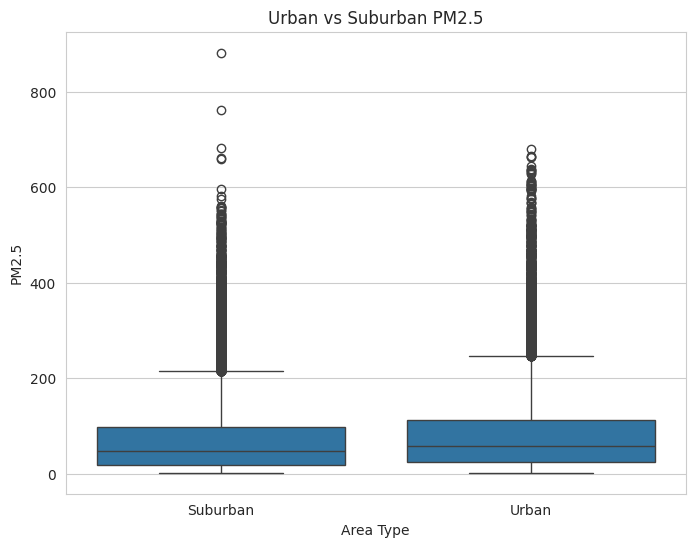

In [43]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="area_type", y="PM2.5")
plt.title("Urban vs Suburban PM2.5")
plt.xlabel("Area Type")
plt.ylabel("PM2.5")
plt.show()

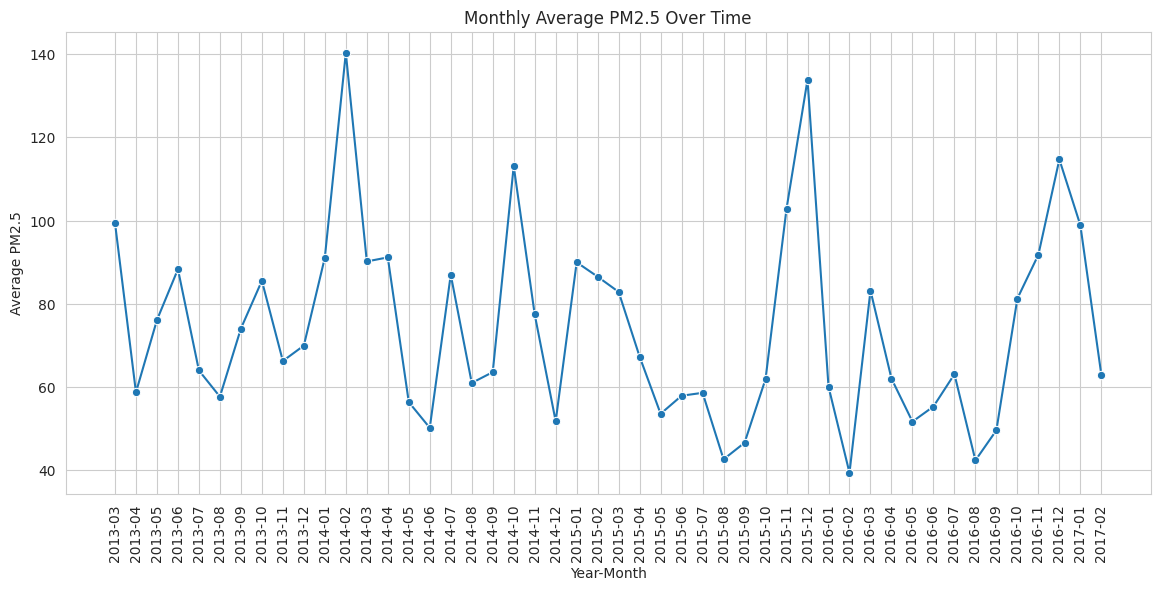

In [44]:
monthly_pm25 = df.groupby(["year", "month"])["PM2.5"].mean().reset_index()
monthly_pm25["year_month"] = (
    monthly_pm25["year"].astype(str) + "-" + monthly_pm25["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_pm25, x="year_month", y="PM2.5", marker="o")
plt.title("Monthly Average PM2.5 Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_12024/768478033.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  station_monthly = df.groupby([pd.Grouper(key="datetime", freq="M"), "station"])["PM2.5"].mean().reset_index()


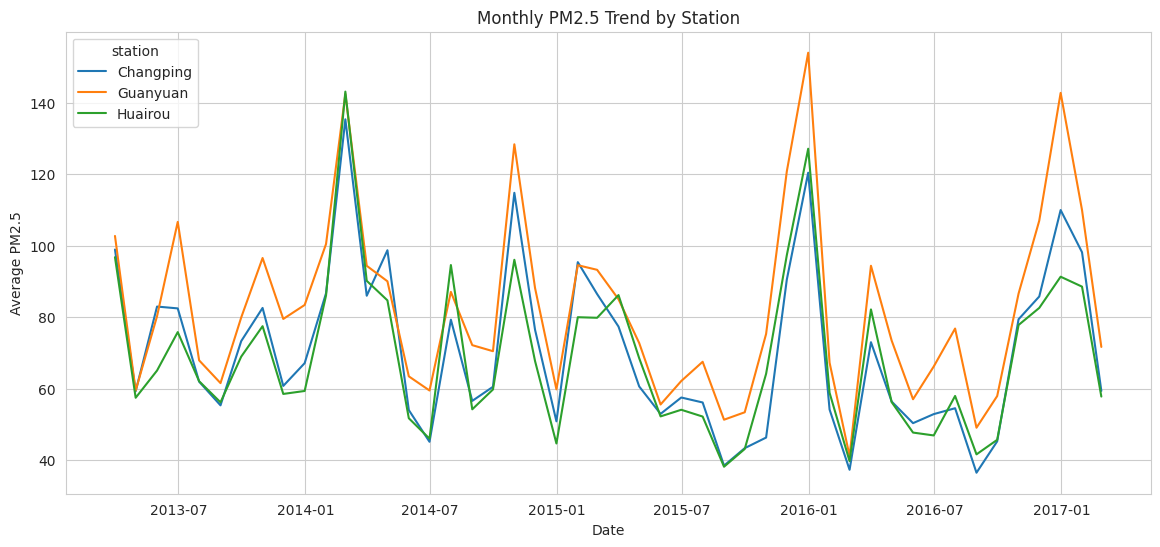

In [45]:
station_monthly = df.groupby([pd.Grouper(key="datetime", freq="M"), "station"])["PM2.5"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=station_monthly, x="datetime", y="PM2.5", hue="station")
plt.title("Monthly PM2.5 Trend by Station")
plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.show()

In [47]:
! git config --global user.name "Asif1900" # replace with your username that you used to create the Github account
! git config --global user.email "asifabdullah1900@gmail.com" # and the email id which you have used to create account

In [48]:
username = "Asif1900" #replace with your own user name
repo = "Programming-for-Data-Analysis-Project"  #replace with your required repo

In [49]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-Project'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 11 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 2.80 MiB | 4.54 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [50]:
%cd {repo}

/content/Programming-for-Data-Analysis-Project/Programming-for-Data-Analysis-Project


In [51]:
%ls

 Programming_for_Data_Analysis_Project.ipynb
 PRSA_Data_Changping_20130301-20170228.csv
'PRSA_Data_Dongsi_20130301-20170228 (1).csv'
 PRSA_Data_Dongsi_20130301-20170228.csv
 PRSA_Data_Guanyuan_20130301-20170228.csv
 PRSA_Data_Huairou_20130301-20170228.csv


In [52]:
# Import the necessary libraries
import pandas as pd  # pandas is used for working with data tables
import glob         # glob is used to find files by name patterns

# STEP 1: The pattern "*_data.csv" means "find all files that end with '_data.csv'"
# This will find files like: Ahmedabad_data.csv, Delhi_data.csv, Mumbai_data.csv, etc.
city_files = glob.glob("*20170228.csv")

# STEP 2: Create an empty list to store all our city data
# We'll put each city's data in this list before combining them
all_cities_data = []

# STEP 3: Read each city file one by one
for file_name in city_files:
    # Read the current city's CSV file into a DataFrame
    # A DataFrame is like a spreadsheet table in Python
    city_df = pd.read_csv(file_name)

    # Add this city's data to our list
    all_cities_data.append(city_df)

    # Optional: Print which file we just read
    print(f"Loaded: {file_name}")

# STEP 4: Combine all city data into one big table
# pd.concat() joins all the DataFrames in our list together
# ignore_index=True makes sure the row numbers are continuous (0, 1, 2, 3...)
combined_data = pd.concat(all_cities_data, ignore_index=True)

# STEP 5: Save the combined data to a new CSV file
# index=False means don't save the row numbers as a separate column
combined_data.to_csv("all_cities_combined.csv", index=False)

# STEP 6: Show us what we accomplished
# len(city_files) = count of how many city files we combined
# len(combined_data) = total number of rows in the final combined file
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv
Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


In [53]:
df= pd.read_csv('all_cities_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou
